# **Credit_Card_Churn**

## **Business Understanding**

**Customer Churn Analysis**
* Customer churn occurs when customers stop using a company's services.
* This project analyzes bank customer data to understand the factors that influence customer churn.

**-> Objective**
* The objective of this analysis is to identify patterns and key factors that contribute to cutomer churn.

In [1]:
# Import Important Libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
# Load Dataset
df = pd.read_csv("/content/drive/MyDrive/Data-Science Intern Assignments Projects/Credit_Card_Churn.csv")
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [5]:
df.head() #1st 5rows

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.shape # Dataset Shape

(10000, 14)

* The dataset contains, 10,000 customer record and 14 features.

In [7]:
df.columns # columns Names

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

**Imporatant **
* Target variable: **Excited**

In [9]:
df.info() # Dataset Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


* The dataset contains both numerical and categorical features such as credit score, age, geography, and account balance.

In [12]:
df.describe() # Statistical Summary -> helps to understand the distribution and range of numerical features.

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [14]:
df.isnull().sum() # Check Missing Values

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


* No missing values were found in the dataset.

In [15]:
df.duplicated().sum() # Check Duplicated Values

np.int64(0)

* No duplicates values were found in dataset.

In [16]:
# Drop Irrelevant Columns: (columns which are not used in analysis):
df.drop(["RowNumber", "CustomerId", "Surname"], axis=1, inplace=True)

* These columns were removed because they do not provide useful information for churn analysis.

In [18]:
# Target Variable Analysis
df["Exited"].value_counts()

,count
Exited,
0,7963
1,2037


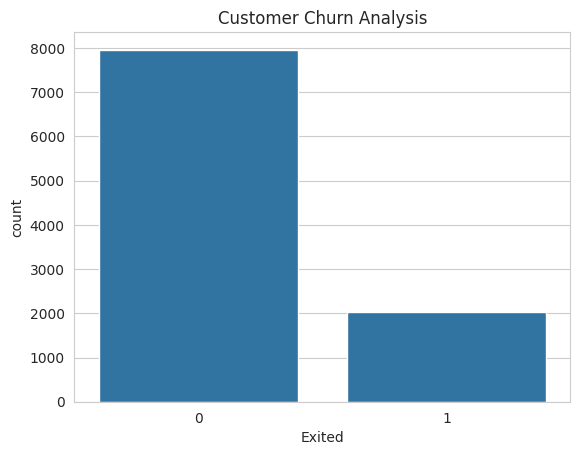

In [19]:
# Visulization:
sns.countplot(x="Exited", data=df)

plt.title("Customer Churn Analysis")
plt.show()

* The majority of customers remain with the bank, while a smaller percentage have exited.

In [21]:
# Churn Rate
df["Exited"].mean()

np.float64(0.2037)

* The overall churn rate is approximately 20%

**EDA PROCESSES**

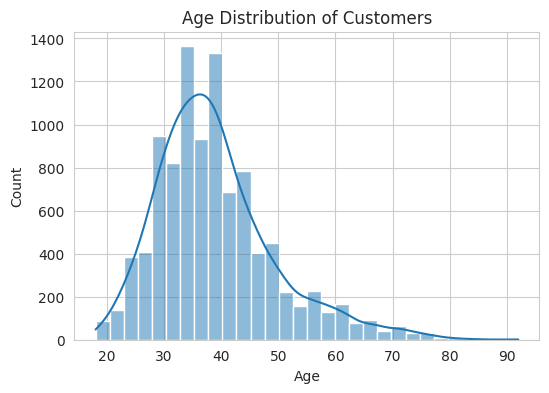

In [23]:
# Univariate Analysis

plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=30, kde=True)

plt.title("Age Distribution of Customers")
plt.show()

* Most customers belongs to the age group between 30 and 45 years

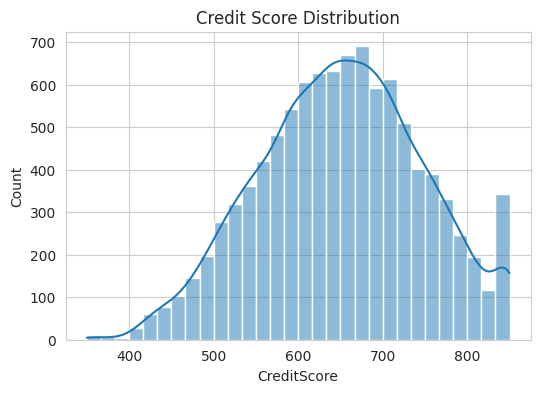

In [24]:
# Visualization :- Credit Score Distribution:-

plt.figure(figsize=(6,4))

sns.histplot(df["CreditScore"], bins=30, kde=True)

plt.title("Credit Score Distribution")
plt.show()

* Most customers have credit scores between 600 and 750.

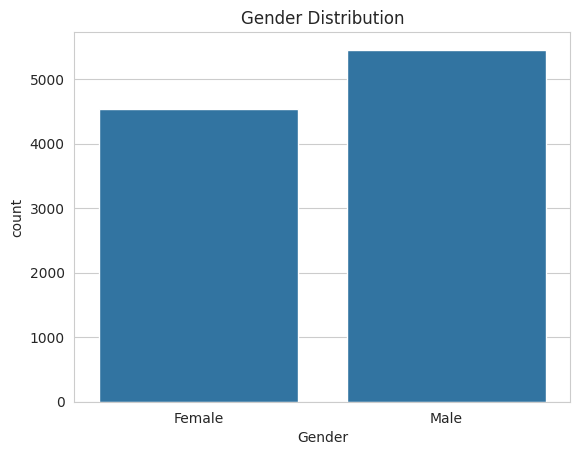

In [25]:
# Visualization:- Gender Distribution:

sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")
plt.show()

* The dataset contains both male and female customrs.

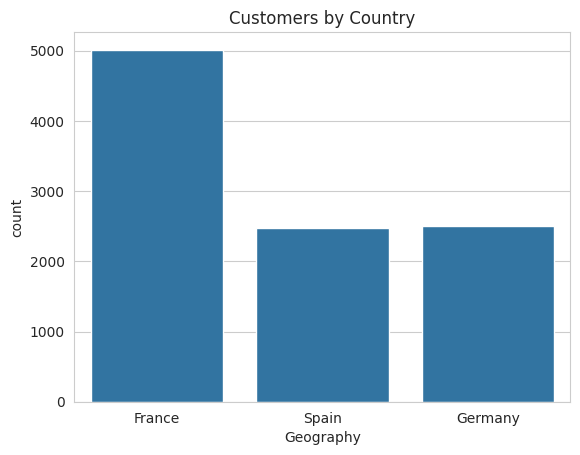

In [26]:
# Visualization:- Geography Distribution:

sns.countplot(x="Geography", data=df)

plt.title("Customers by Country")
plt.show()

* Most of the customers are form France followed by Germany and Spain.

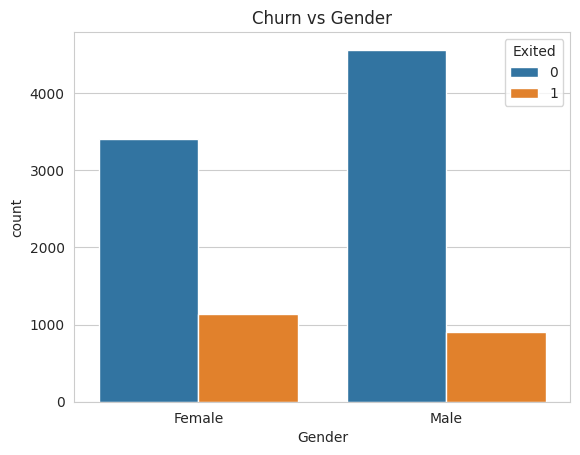

In [27]:
# Bivariate Analysis:
# Visualization:- Churn vs Gender:

sns.countplot(x="Gender", hue="Exited", data=df)

plt.title("Churn vs Gender")
plt.show()

* Female customers show slightly higher churn compared to male customers.

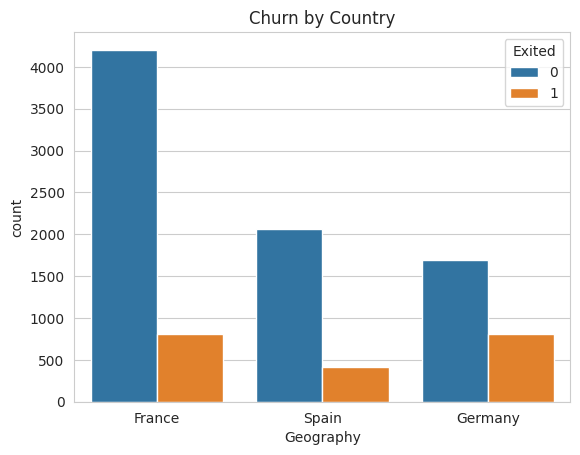

In [28]:
# Visualization:- Churn vs Geography:

sns.countplot(x="Geography", hue="Exited", data=df)

plt.title("Churn by Country")
plt.show()

* Customers from France and Germany have higher churn as compared to Spain.
* France and Germany have churn rate almost simliar to each other.

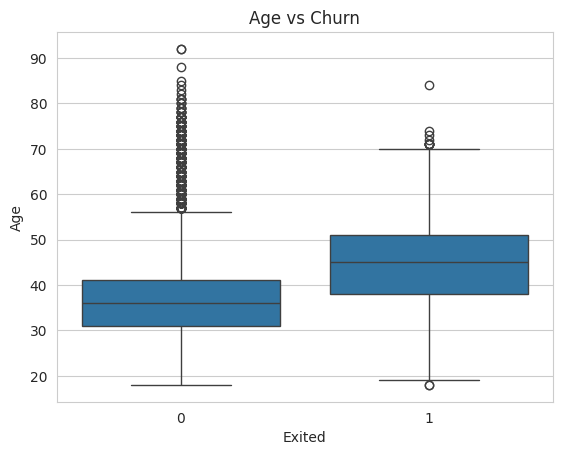

In [29]:
# Visualization:- Age vc Churn

sns.boxplot(x="Exited", y="Age", data=df)

plt.title("Age vs Churn")
plt.show()

* Older customers appear more likely to churn.

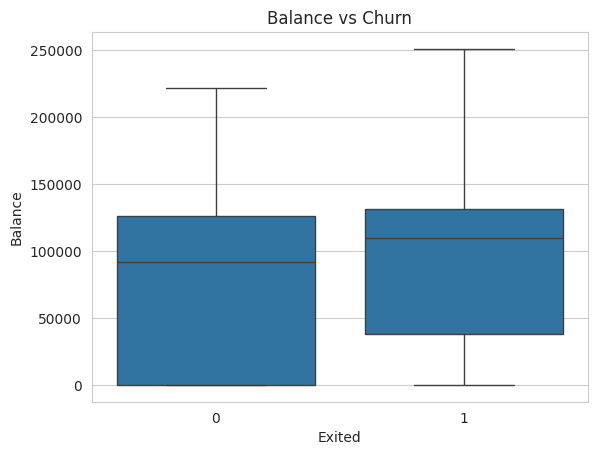

In [30]:
# Visualization:- Balance vs Churn

sns.boxplot(x="Exited", y="Balance", data=df)

plt.title("Balance vs Churn")
plt.show()

* Customers with higher balance tend to churn more.

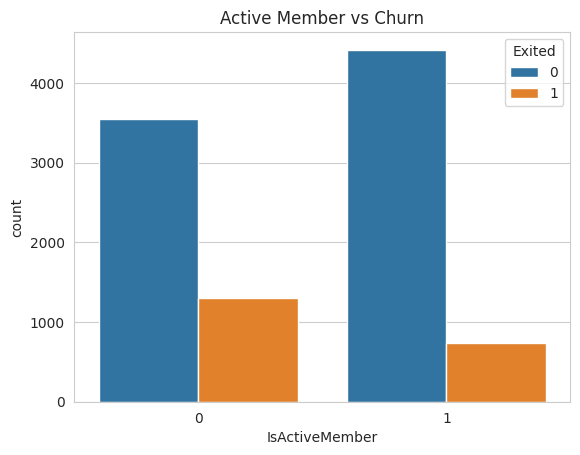

In [31]:
# Visualization:- Active Member vs Churn:

sns.countplot(x="IsActiveMember", hue="Exited", data=df)

plt.title("Active Member vs Churn")
plt.show()

* Inactive customers have higher churn rates.

**CORRELATION ANALYSIS**

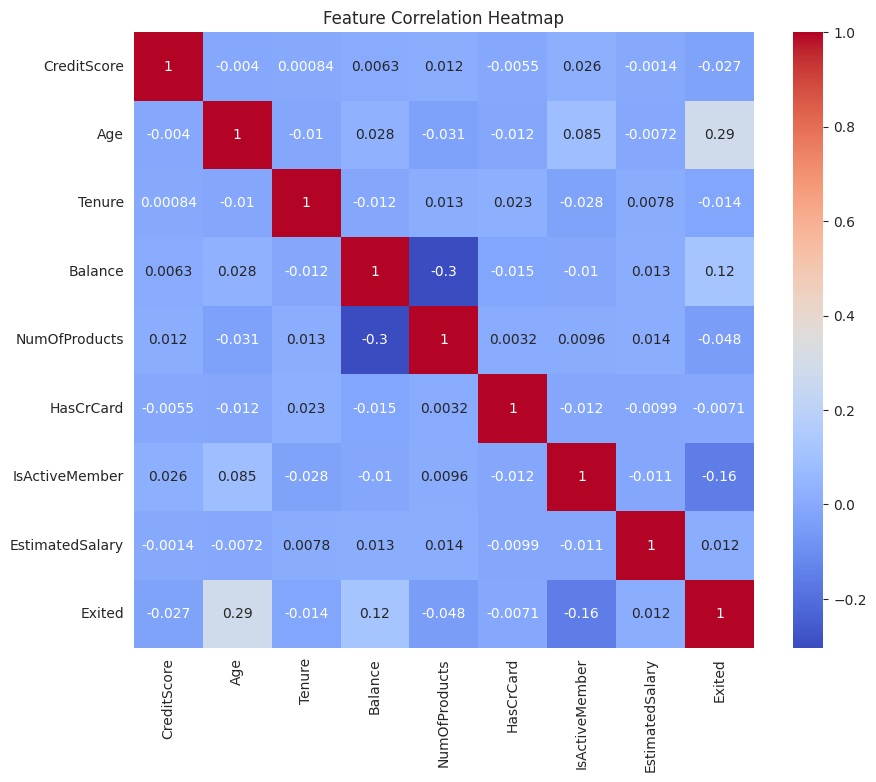

In [34]:
plt.figure(figsize=(10,8))

# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=['number'])
sns.heatmap(numerical_df.corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()

* Purpose:
  * Feature relationships
  * Important variables

**Customer Segmentation:- ADVANCED EDA**

Geography
France     0.161548
Germany    0.324432
Spain      0.166734
Name: Exited, dtype: float64


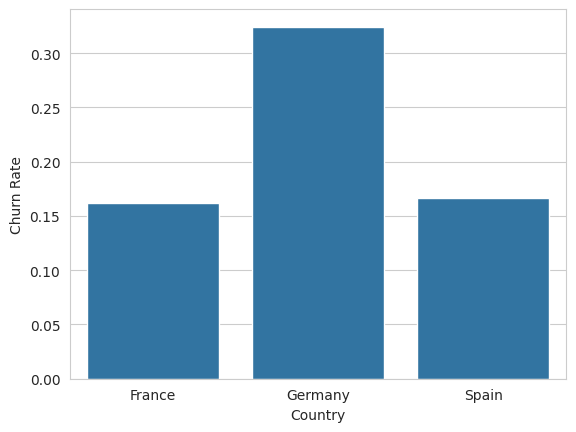

In [35]:
# Customer Segmentation by Country:

country_churn = df.groupby("Geography")["Exited"].mean()
print(country_churn)

# Visualization:-

sns.barplot(x=country_churn.index, y=country_churn.values)
plt.ylabel("Churn Rate")
plt.xlabel("Country")
plt.show()

* Customers from Germany show the highest churn rate compared to France and Spain.

AgeGroup
(18, 30]     0.075026
(30, 40]     0.120872
(40, 50]     0.339655
(50, 60]     0.562108
(60, 100]    0.247845
Name: Exited, dtype: float64


/tmp/ipykernel_383/133983174.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_churn = df.groupby("AgeGroup")["Exited"].mean()


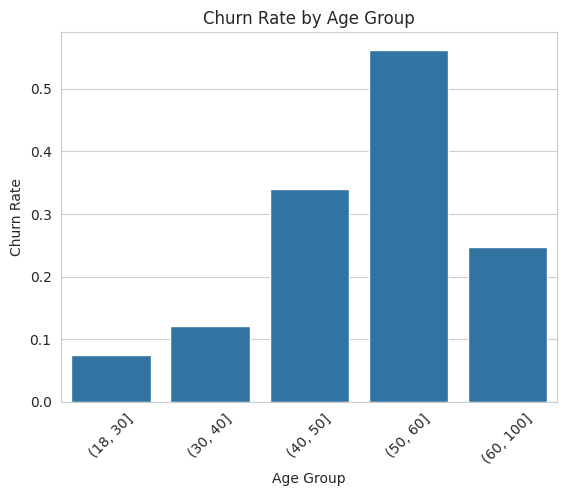

In [37]:
# Age Group Segmentation:-

df["AgeGroup"] = pd.cut(df["Age"], bins=[18, 30, 40, 50, 60, 100])

age_churn = df.groupby("AgeGroup")["Exited"].mean()
print(age_churn)

# Visualization:

sns.barplot(x=age_churn.index, y=age_churn.values)
plt.title("Churn Rate by Age Group")
plt.xticks(rotation=45)
plt.xlabel("Age Group")
plt.ylabel("Churn Rate")
plt.show()

* Customers aged 50-60 have higher churn rates compared to youngers customers.

NumOfProducts
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: Exited, dtype: float64


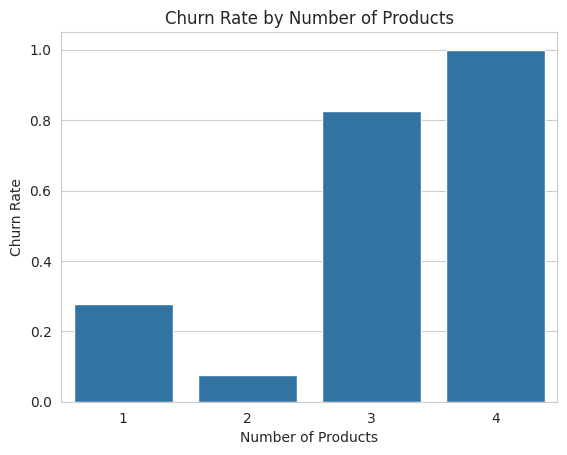

In [38]:
# Product-wise Segmentation:-

product_churn = df.groupby("NumOfProducts")["Exited"].mean()
print(product_churn)

# Visualization:

sns.barplot(x=product_churn.index, y=product_churn.values)
plt.title("Churn Rate by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate")
plt.show()

* Customers with only one product have higher churn rates.

IsActiveMember
0    0.268509
1    0.142691
Name: Exited, dtype: float64


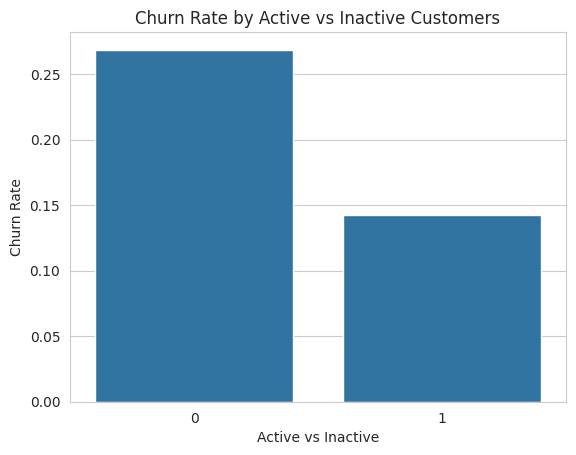

In [39]:
# Active vs Inactive Customers:-

active_inactive_churn = df.groupby("IsActiveMember")["Exited"].mean()
print(active_inactive_churn)

# Visualization:

sns.barplot(x=active_inactive_churn.index, y=active_inactive_churn.values)
plt.title("Churn Rate by Active vs Inactive Customers")
plt.xlabel("Active vs Inactive")
plt.ylabel("Churn Rate")
plt.show()

* Inactive customers churn significantly more than active customers.

BalanceGroup
(-0.001, 97198.54]        0.1576
(97198.54, 127644.24]     0.2628
(127644.24, 250898.09]    0.2368
Name: Exited, dtype: float64


/tmp/ipykernel_383/2955410086.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  balance_churn = df.groupby("BalanceGroup")["Exited"].mean()


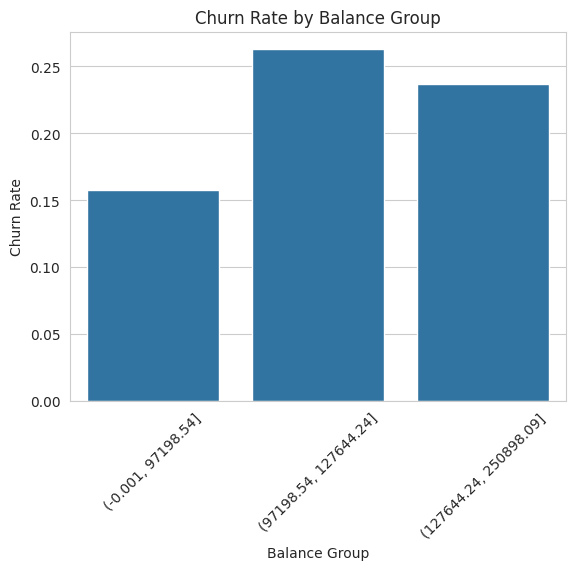

In [43]:
# Balance Segmentation:-

df["BalanceGroup"] = pd.qcut(df["Balance"], q=4, duplicates="drop")

balance_churn = df.groupby("BalanceGroup")["Exited"].mean()
print(balance_churn)

# Visualization:

sns.barplot(x=balance_churn.index, y=balance_churn.values)
plt.title("Churn Rate by Balance Group")
plt.xticks(rotation=45)
plt.xlabel("Balance Group")
plt.ylabel("Churn Rate")
plt.show()

**Final Insights**

* Germany customers show highest chura rate
* Customers aged 50-60 churn more frequently
* Customers with only one product churn more
* Inactive members have highest churn probability
* High balance customers tend to churn more

**Business Recommendations**

* Improve engagement with inactive customers
* Encourage customers to use multiple products
* Provide personalized offers to high-balance customers
* Target high-risk age groups with retention campaigns